# Evidência: histograma de KM antes/depois da limpeza de outliers

Script solto (não faz parte do pipeline de produção) para gerar a evidência visual pedida na issue: histogramas lado a lado de `KM` antes/depois da winsorização, usando a função de domínio `winsorize_km` (`src/domain/km_cleaning.py`).

In [1]:
import sys
import pathlib

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(pathlib.Path("..").resolve()))
from src.domain.km_cleaning import winsorize_km

RAW_PATH = "../data/raw/vin_share.zip"
OUTPUT_PNG = "km_histogram_before_after.png"
ABSURD_THRESHOLD = 1_000_000  # km acima disso é visualmente incoerente

In [2]:
df = pd.read_csv(RAW_PATH, compression="zip", low_memory=False)

km_before = df["KM"]
km_after = winsorize_km(km_before)  # winsorização no p99 (src/domain/km_cleaning.py)

print(f"Linhas: {len(df):,}")
print(f"KM antes  -> min={km_before.min():,.0f}  max={km_before.max():,.0f}")
print(f"KM depois -> min={km_after.min():,.0f}  max={km_after.max():,.0f}")

Linhas: 602,788
KM antes  -> min=0  max=955,388,451
KM depois -> min=0  max=145,724


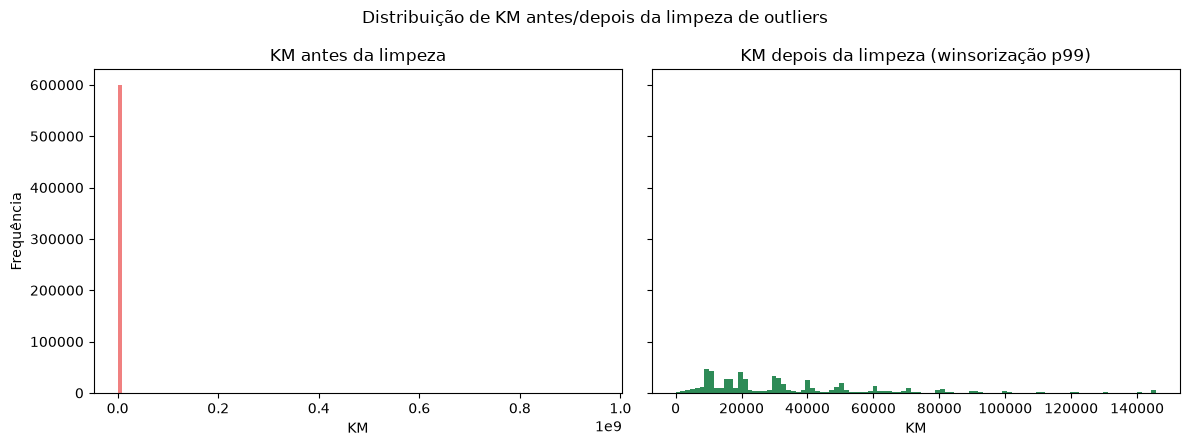

Gráfico salvo em: C:\Users\bruno\Desktop\challenge_next\ford-next\backend\notebooks\km_histogram_before_after.png


In [3]:
fig, (ax_before, ax_after) = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

ax_before.hist(km_before.dropna(), bins=100, color="lightcoral")
ax_before.set_title("KM antes da limpeza")
ax_before.set_xlabel("KM")
ax_before.set_ylabel("Frequência")

ax_after.hist(km_after.dropna(), bins=100, color="seagreen")
ax_after.set_title("KM depois da limpeza (winsorização p99)")
ax_after.set_xlabel("KM")

fig.suptitle("Distribuição de KM antes/depois da limpeza de outliers")
fig.tight_layout()
fig.savefig(OUTPUT_PNG, dpi=150)
plt.show()

print(f"Gráfico salvo em: {pathlib.Path(OUTPUT_PNG).resolve()}")

In [4]:
n_absurdos_antes = (km_before > ABSURD_THRESHOLD).sum()
n_absurdos_depois = (km_after > ABSURD_THRESHOLD).sum()

print(f"Valores > {ABSURD_THRESHOLD:,} km ANTES da limpeza:  {n_absurdos_antes:,}")
print(f"Valores > {ABSURD_THRESHOLD:,} km DEPOIS da limpeza: {n_absurdos_depois:,}")

assert n_absurdos_depois == 0, "Ainda restam valores de KM visualmente incoerentes (> 10^6 km) apos a limpeza"
print("\nOK - nenhum valor visualmente incoerente (> 10^6 km) remanescente apos a limpeza.")

Valores > 1,000,000 km ANTES da limpeza:  41
Valores > 1,000,000 km DEPOIS da limpeza: 0

OK - nenhum valor visualmente incoerente (> 10^6 km) remanescente apos a limpeza.
